In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("..") / "ExperimentRunner" / "experiment_results"

supported = {".csv", ".json", ".jsonl", ".parquet"}
files = sorted(
    p for p in results_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in supported
)

def load_experiment_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".json":
        data = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(data, list):
            return pd.json_normalize(data)
        if isinstance(data, dict):
            return pd.json_normalize(data)
        return pd.DataFrame({"value": [data]})
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    raise ValueError(f"Unsupported file type: {path}")

csv_path = next((p for p in files if p.suffix.lower() == ".csv"), None)
if csv_path is None:
    raise FileNotFoundError("No .csv experiment file found in 'files'.")

csv_df = load_experiment_file(csv_path).copy()
csv_df = csv_df.sort_values(["Instance", "Evaluations"])
csv_df


,Instance,Algorithm,Params,Seed,BestCost,Evaluations,ElapsedMs,BestFoundAt,Timestamp
18,tai_100_10_0,Random_1_s123,RandomParameters,123,399175,1,0.0654,1,2026-03-16T09:14:07.8920265+00:00
19,tai_100_10_0,Random_10_s123,RandomParameters,123,381715,10,0.4566,9,2026-03-16T09:14:07.8939013+00:00
20,tai_100_10_0,Random_100_s123,RandomParameters,123,373078,100,2.7495,29,2026-03-16T09:14:07.8984901+00:00
21,tai_100_10_0,Random_1000_s123,RandomParameters,123,366190,1000,24.3115,564,2026-03-16T09:14:07.9244034+00:00
22,tai_100_10_0,Random_10000_s123,RandomParameters,123,361571,10000,232.2822,1706,2026-03-16T09:14:08.1603504+00:00
23,tai_100_10_0,Random_100000_s123,RandomParameters,123,358641,100000,1877.4634,56914,2026-03-16T09:14:10.0399739+00:00
24,tai_100_20_0,Random_1_s123,RandomParameters,123,471635,1,0.0727,1,2026-03-16T09:14:10.0418205+00:00
25,tai_100_20_0,Random_10_s123,RandomParameters,123,461315,10,0.5374,6,2026-03-16T09:14:10.0438130+00:00
26,tai_100_20_0,Random_100_s123,RandomParameters,123,452686,100,3.1885,21,2026-03-16T09:14:10.0484888+00:00
27,tai_100_20_0,Random_1000_s123,RandomParameters,123,442531,1000,54.5909,837,2026-03-16T09:14:10.1040345+00:00


In [1]:
import subprocess
from pathlib import Path

repo_root = Path.cwd().resolve().parent
config_path = repo_root / "Analysis" / "experimentrunner.default_all_instances.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(result.stdout)
if result.stderr.strip():
    print("STDERR:\n" + result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {result.returncode}")
print("ExperimentRunner finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\Optimization_methods\Analysis\experimentrunner.default_all_instances.json
Experiment Runner
Running Random_10000_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Random_10000_s0,RandomParameters,0,15335,10000,66.9382,-1,2026-03-19T10:39:59.0739939+00:00
Running Evolutionary_p100_g100_s0 on tai_20_5_0 (seed 0)...
tai_20_5_0,Evolutionary_p100_g100_s0,EvolutionaryParameters,0,14293,10100,82.5713,4842,2026-03-19T10:39:59.1633212+00:00
Running Greedy on tai_20_5_0...
tai_20_5_0,Greedy,GreedyParameters,,14286,1,10.5163,-1,2026-03-19T10:39:59.1746986+00:00
Running Random_10000_s0 on tai_20_10_0 (seed 0)...
tai_20_10_0,Random_10000_s0,RandomParameters,0,23273,10000,115.3603,-1,2026-03-19T10:39:59.2976628+00:00
Running Evolutionary_p100_g100_s0 on tai_20_10_0 (seed 0)...
tai_20_10_0,Evolutionary_p100_g100_s0,EvolutionaryParameters,0,21649,10100,165.3025,7180,2026-03-19T10:39:59.4646694+00:00
Running Greedy on tai_20_1

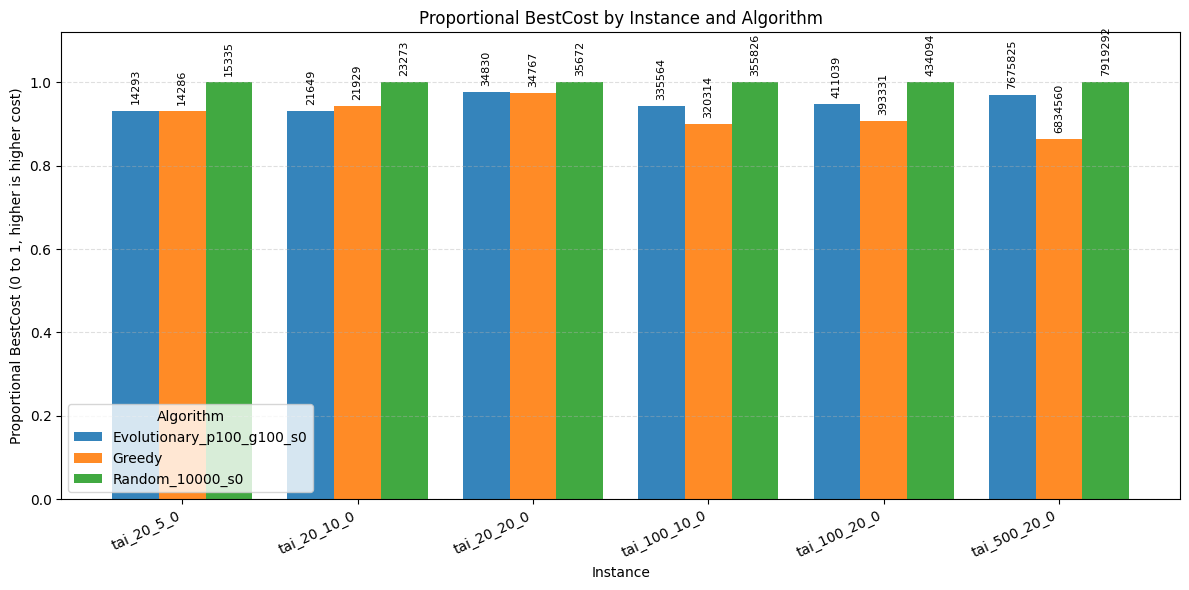

Algorithm,Evolutionary_p100_g100_s0,Greedy,Random_10000_s0
Instance,,,
tai_20_5_0,0.932051,0.931594,1.0
tai_20_10_0,0.930220,0.942251,1.0
tai_20_20_0,0.976396,0.974630,1.0
tai_100_10_0,0.943056,0.900198,1.0
tai_100_20_0,0.946889,0.906096,1.0
tai_500_20_0,0.969256,0.863027,1.0


In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

candidate_paths = [
    Path("Experiments") / "experiment_study.csv",
    Path("..") / "ExperimentRunner" / "Analysis" / "Experiments" / "experiment_study.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    searched = "\n".join(str(p.resolve()) for p in candidate_paths)
    raise FileNotFoundError(f"Could not find experiment_study.csv. Searched:\n{searched}")

df = pd.read_csv(csv_path)
instance_order = df["Instance"].drop_duplicates().tolist()

pivot = df.pivot_table(
    index="Instance",
    columns="Algorithm",
    values="BestCost",
    aggfunc="min",
)
pivot = pivot.reindex(instance_order)

# Per-instance proportional score in [0, 1] with no inversion: 1 = highest cost.
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

instances = score_pivot.index.to_list()
algorithms = score_pivot.columns.to_list()
x = np.arange(len(instances))
width = 0.8 / max(len(algorithms), 1)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, alg in enumerate(algorithms):
    offset = (idx - (len(algorithms) - 1) / 2) * width
    heights = score_pivot[alg].values
    bars = ax.bar(
        x + offset,
        heights,
        width=width,
        label=alg,
        alpha=0.9,
    )

    # Show original BestCost values on bars.
    for bar, cost in zip(bars, pivot[alg].values):
        if pd.notna(cost):
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.015,
                f"{int(cost)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("Proportional BestCost by Instance and Algorithm")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Algorithm")
plt.tight_layout()
plt.show()

score_pivot

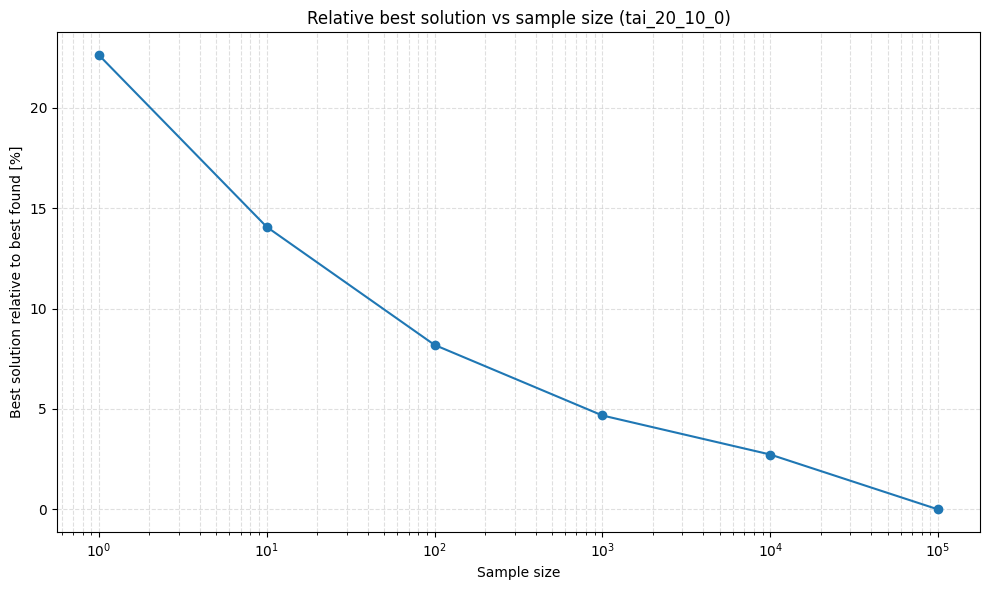

In [9]:

target_instance = "tai_20_10_0"
instance_df = csv_df[csv_df["Instance"] == target_instance].copy()
if instance_df.empty:
    raise ValueError(f"Instance '{target_instance}' not found in {csv_path.name}.")

best_cost = instance_df["BestCost"].min()
instance_df["RelativeBestCostPct"] = ((instance_df["BestCost"] / best_cost) - 1.0) * 100.0

ax = instance_df.plot(
    x="Evaluations",
    y="RelativeBestCostPct",
    marker="o",
    figsize=(10, 6),
    logx=True,
    legend=False,
    color="#1f77b4",
)

ax.set_xlabel("Sample size")
ax.set_ylabel("Best solution relative to best found [%]")
ax.set_title(f"Relative best solution vs sample size ({target_instance})")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()